In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path('../data')
panel = pd.read_csv(DATA_DIR / 'panel.csv', parse_dates=['month_end'])
print(f'Shape: {panel.shape}')
print(f'Columns: {list(panel.columns)}')
print(f'Month range: {panel["month_end"].min()} to {panel["month_end"].max()}')
print(f'States: {panel["state"].nunique()}')
print(f'Worker types: {sorted(panel["worker_type"].unique())}')

# Overall weighted rates by worker type
for wt in ['Employee', 'Contract']:
    sub = panel[panel['worker_type'] == wt]
    r = sub['separation_count'].sum() / sub['active_count'].sum()
    print(f'  {wt}: {r:.4f} monthly ({1-(1-r)**12:.1%} annualized)')

panel.head(10)

Shape: (35340, 8)
Columns: ['state', 'ownership', 'role', 'worker_type', 'month_end', 'active_count', 'separation_count', 'separation_rate']
Month range: 2022-10-01 00:00:00 to 2025-12-01 00:00:00
States: 53
Worker types: ['Contract', 'Employee']
  Employee: 0.0759 monthly (61.2% annualized)
  Contract: 0.3638 monthly (99.6% annualized)


,state,ownership,role,worker_type,month_end,active_count,separation_count,separation_rate
0,AK,For-Profit,CNA,Contract,2022-10-01,7,2,0.285714
1,AK,For-Profit,CNA,Contract,2022-11-01,7,1,0.142857
2,AK,For-Profit,CNA,Contract,2022-12-01,11,1,0.090909
3,AK,For-Profit,CNA,Contract,2023-01-01,17,4,0.235294
4,AK,For-Profit,CNA,Contract,2023-02-01,14,4,0.285714
5,AK,For-Profit,CNA,Contract,2023-03-01,12,4,0.333333
6,AK,For-Profit,CNA,Contract,2023-04-01,10,2,0.200000
7,AK,For-Profit,CNA,Contract,2023-05-01,8,1,0.125000
8,AK,For-Profit,CNA,Contract,2023-06-01,13,3,0.230769
9,AK,For-Profit,CNA,Contract,2023-07-01,10,2,0.200000


## 1. Employee vs Contract Separation Rates Over Time

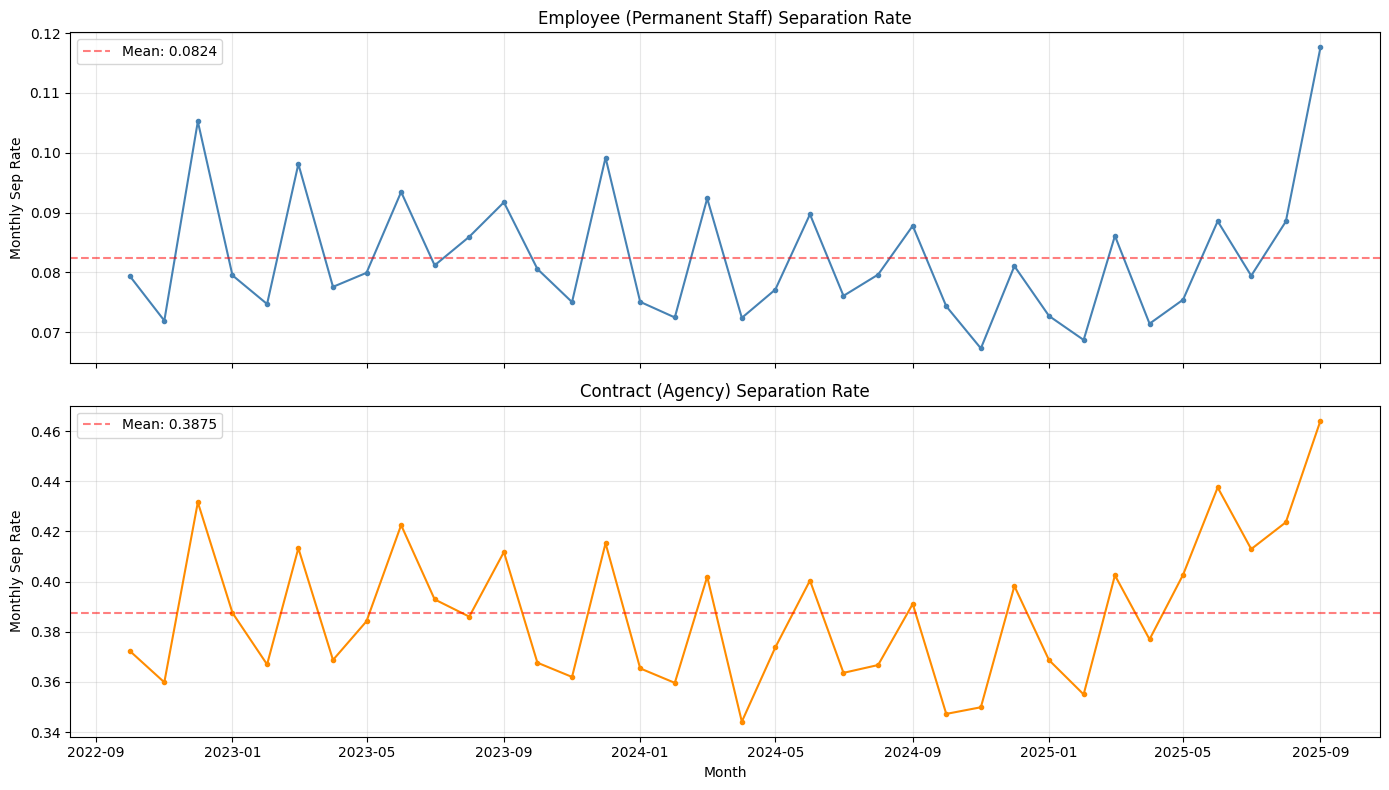

In [2]:
# Exclude right-censored tail (Oct-Dec 2025)
clean = panel[panel['month_end'] <= '2025-09-30'].copy()

wt_monthly = clean.groupby(['month_end', 'worker_type']).agg(
    total_active=('active_count', 'sum'),
    total_seps=('separation_count', 'sum'),
).reset_index()
wt_monthly['rate'] = wt_monthly['total_seps'] / wt_monthly['total_active']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

emp = wt_monthly[wt_monthly['worker_type'] == 'Employee']
ctr = wt_monthly[wt_monthly['worker_type'] == 'Contract']

ax1.plot(emp['month_end'], emp['rate'], marker='o', markersize=3, color='steelblue')
ax1.axhline(emp['rate'].mean(), color='red', linestyle='--', alpha=0.5, label=f"Mean: {emp['rate'].mean():.4f}")
ax1.set_ylabel('Monthly Sep Rate')
ax1.set_title('Employee (Permanent Staff) Separation Rate')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(ctr['month_end'], ctr['rate'], marker='o', markersize=3, color='darkorange')
ax2.axhline(ctr['rate'].mean(), color='red', linestyle='--', alpha=0.5, label=f"Mean: {ctr['rate'].mean():.4f}")
ax2.set_ylabel('Monthly Sep Rate')
ax2.set_title('Contract (Agency) Separation Rate')
ax2.set_xlabel('Month')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Employee-Only Analysis (Primary Signal)

From here on, we focus exclusively on permanent employees — the policy-relevant workforce.

In [3]:
emp_panel = clean[clean['worker_type'] == 'Employee'].copy()
emp_monthly = emp_panel.groupby('month_end').agg(
    total_active=('active_count', 'sum'),
    total_seps=('separation_count', 'sum'),
).reset_index()
emp_monthly['rate'] = emp_monthly['total_seps'] / emp_monthly['total_active']
emp_monthly['cal_month'] = emp_monthly['month_end'].dt.month

print(f"Employee panel: {len(emp_panel)} rows, {emp_panel['month_end'].nunique()} months")
print(f"Mean monthly rate: {emp_monthly['rate'].mean():.4f} ({1-(1-emp_monthly['rate'].mean())**12:.1%} annualized)")

Employee panel: 16518 rows, 36 months
Mean monthly rate: 0.0824 (64.4% annualized)


## 3. National Monthly Employee Separation Rate

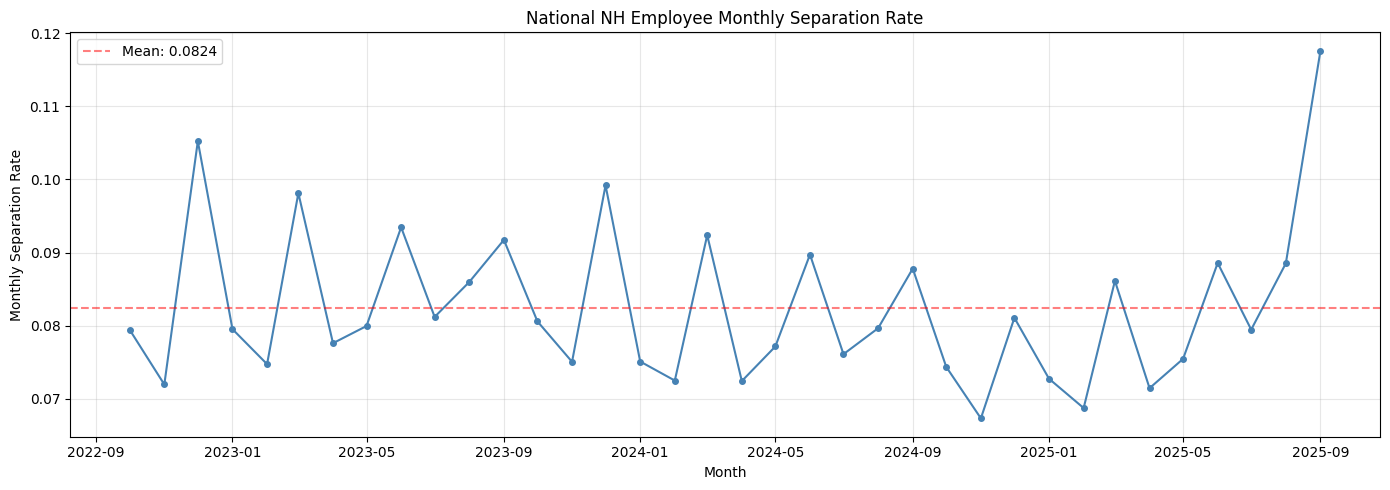

In [4]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(emp_monthly['month_end'], emp_monthly['rate'], marker='o', markersize=4, color='steelblue')
ax.axhline(emp_monthly['rate'].mean(), color='red', linestyle='--', alpha=0.5, label=f"Mean: {emp_monthly['rate'].mean():.4f}")
ax.set_xlabel('Month')
ax.set_ylabel('Monthly Separation Rate')
ax.set_title('National NH Employee Monthly Separation Rate')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Seasonal Pattern (Employee Only)

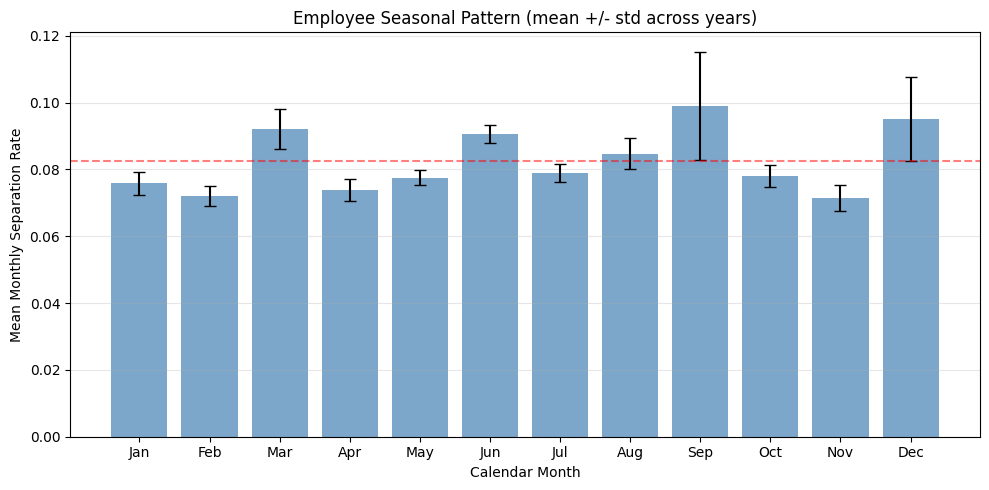

month_name     mean
       Jan 0.075782
       Feb 0.071981
       Mar 0.092210
       Apr 0.073820
       May 0.077516
       Jun 0.090584
       Jul 0.078915
       Aug 0.084713
       Sep 0.099052
       Oct 0.078124
       Nov 0.071439
       Dec 0.095170


In [5]:
seasonal = emp_monthly.groupby('cal_month')['rate'].agg(['mean', 'std']).reset_index()
seasonal['month_name'] = seasonal['cal_month'].apply(lambda m: pd.Timestamp(2024, m, 1).strftime('%b'))

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(seasonal['month_name'], seasonal['mean'], yerr=seasonal['std'], capsize=4, color='steelblue', alpha=0.7)
ax.axhline(emp_monthly['rate'].mean(), color='red', linestyle='--', alpha=0.5)
ax.set_xlabel('Calendar Month')
ax.set_ylabel('Mean Monthly Separation Rate')
ax.set_title('Employee Seasonal Pattern (mean +/- std across years)')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()
print(seasonal[['month_name', 'mean']].to_string(index=False))

## 5. State-Level Distribution (Employee Only)

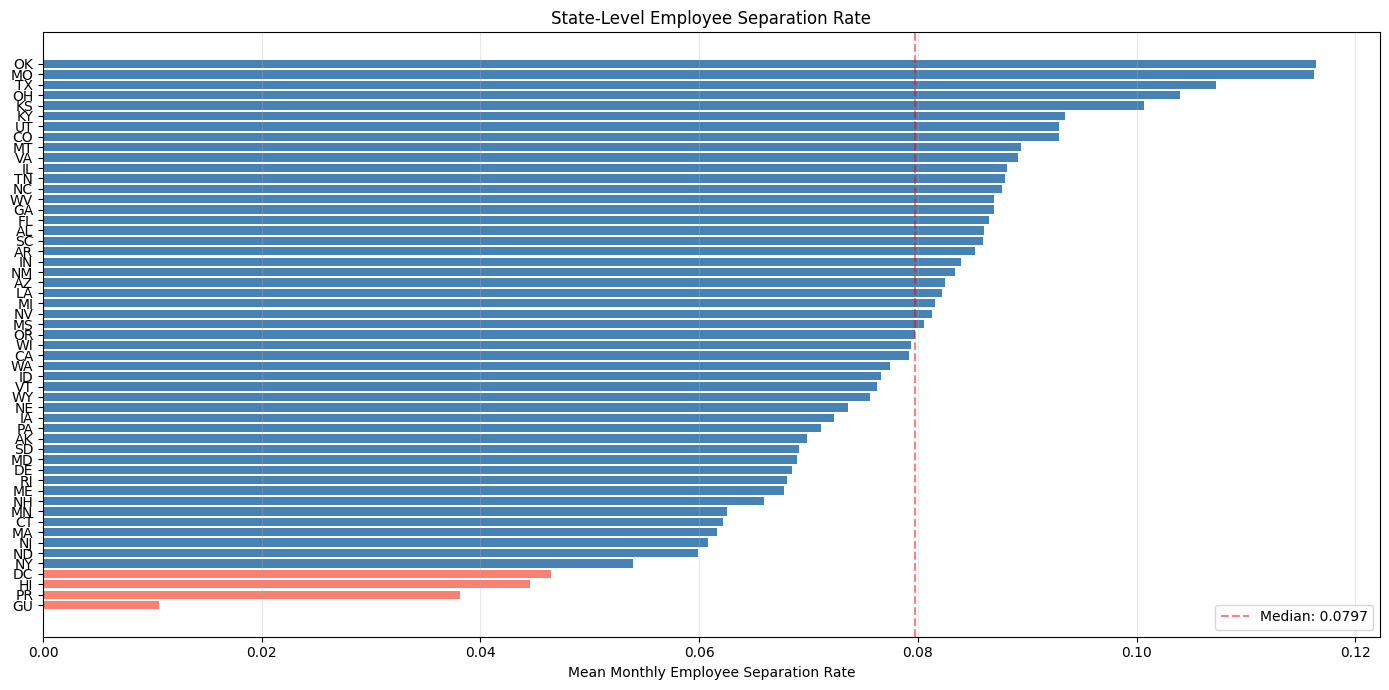

CV: 0.239
Spread (max/min, excl territories): 2.6x
Top 5:
  KS: 0.1007 (72.0% ann.)
  OH: 0.1040 (73.2% ann.)
  TX: 0.1073 (74.4% ann.)
  MO: 0.1162 (77.3% ann.)
  OK: 0.1164 (77.4% ann.)
Bottom 5:
  GU: 0.0106 (12.0% ann.)
  PR: 0.0381 (37.3% ann.)
  HI: 0.0445 (42.1% ann.)
  DC: 0.0464 (43.5% ann.)
  NY: 0.0539 (48.6% ann.)


In [6]:
state_rates = emp_panel.groupby('state', group_keys=False).apply(
    lambda g: pd.Series({'rate': g['separation_count'].sum() / g['active_count'].sum()}),
    include_groups=False
).sort_values('rate')

fig, ax = plt.subplots(figsize=(14, 7))
colors = ['steelblue' if 0.05 <= r <= 0.12 else 'salmon' for r in state_rates['rate']]
ax.barh(state_rates.index, state_rates['rate'], color=colors)
ax.axvline(state_rates['rate'].median(), color='red', linestyle='--', alpha=0.5, label=f"Median: {state_rates['rate'].median():.4f}")
ax.set_xlabel('Mean Monthly Employee Separation Rate')
ax.set_title('State-Level Employee Separation Rate')
ax.legend()
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print(f"CV: {state_rates['rate'].std()/state_rates['rate'].mean():.3f}")
mainland = state_rates[~state_rates.index.isin(['GU', 'PR'])]
print(f"Spread (max/min, excl territories): {mainland['rate'].max()/mainland['rate'].min():.1f}x")
print("Top 5:")
for st in state_rates.index[-5:]:
    r = state_rates.loc[st, 'rate']
    print(f"  {st}: {r:.4f} ({1-(1-r)**12:.1%} ann.)")
print("Bottom 5:")
for st in state_rates.index[:5]:
    r = state_rates.loc[st, 'rate']
    print(f"  {st}: {r:.4f} ({1-(1-r)**12:.1%} ann.)")


## 6. Role-Level Rates (Employee Only)

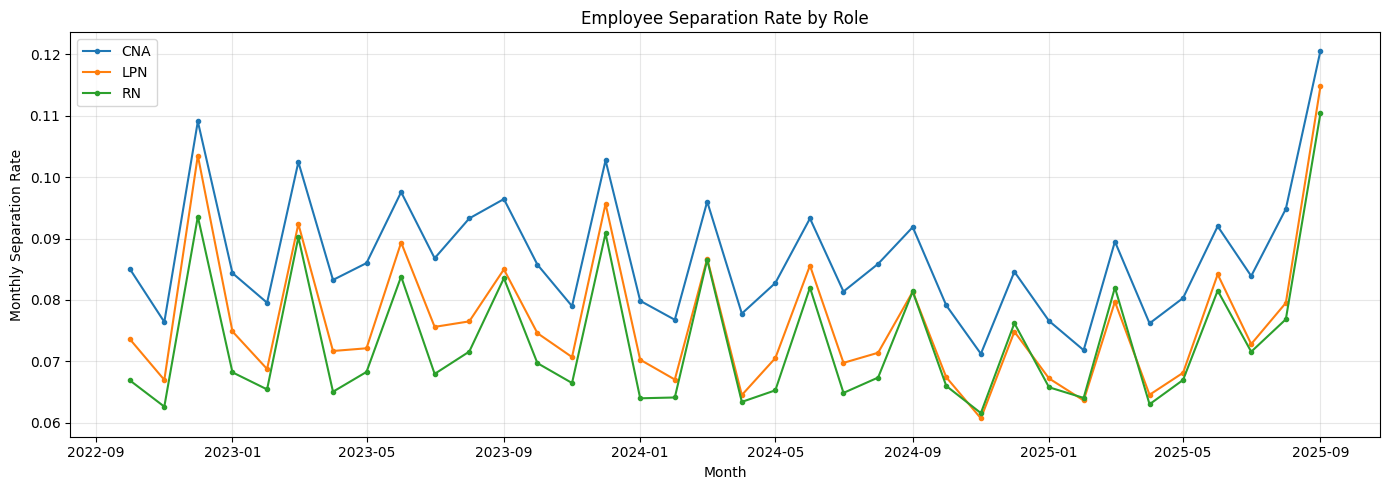

          rate  annualized
role                      
CNA   0.087037    0.664698
LPN   0.076544    0.615411
RN    0.073362    0.599205


In [7]:
role_monthly = emp_panel.groupby(['month_end', 'role']).agg(
    total_active=('active_count', 'sum'),
    total_seps=('separation_count', 'sum'),
).reset_index()
role_monthly['rate'] = role_monthly['total_seps'] / role_monthly['total_active']

fig, ax = plt.subplots(figsize=(14, 5))
for role in ['CNA', 'LPN', 'RN']:
    subset = role_monthly[role_monthly['role'] == role]
    ax.plot(subset['month_end'], subset['rate'], marker='o', markersize=3, label=role)
ax.set_xlabel('Month')
ax.set_ylabel('Monthly Separation Rate')
ax.set_title('Employee Separation Rate by Role')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

role_rates = emp_panel.groupby('role', group_keys=False).apply(
    lambda g: pd.Series({'rate': g['separation_count'].sum() / g['active_count'].sum()}),
    include_groups=False
)
role_rates['annualized'] = 1 - (1 - role_rates['rate'])**12
print(role_rates)

## 7. Ownership Effect (Employee Only)

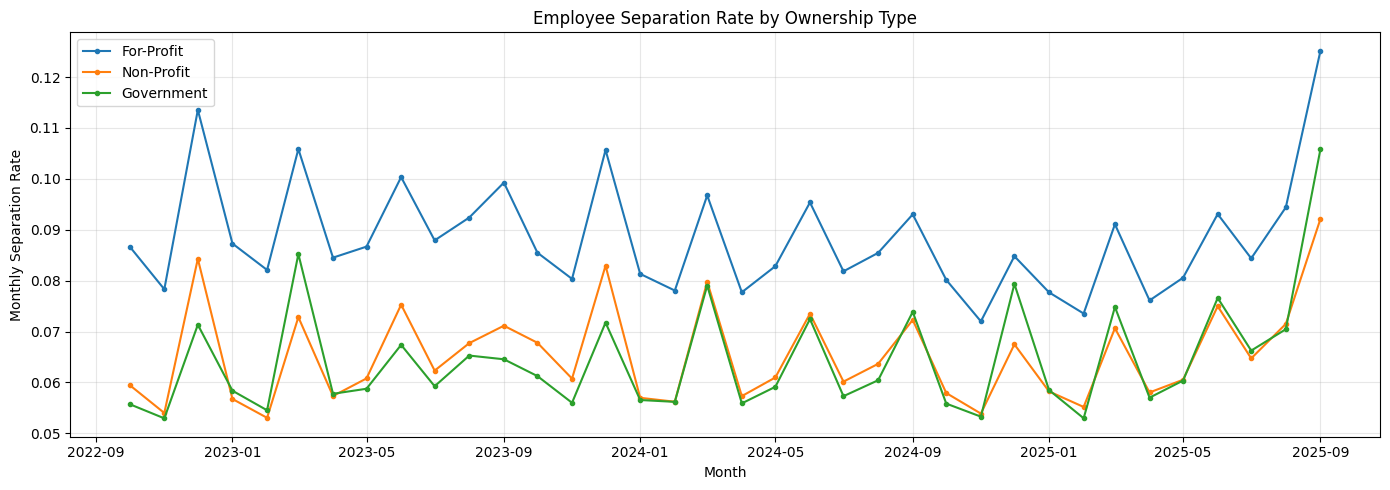

                rate  annualized
ownership                       
For-Profit  0.088340    0.670393
Non-Profit  0.065422    0.555998
Government  0.064670    0.551690


In [8]:
own_monthly = emp_panel.groupby(['month_end', 'ownership']).agg(
    total_active=('active_count', 'sum'),
    total_seps=('separation_count', 'sum'),
).reset_index()
own_monthly['rate'] = own_monthly['total_seps'] / own_monthly['total_active']

fig, ax = plt.subplots(figsize=(14, 5))
for own in ['For-Profit', 'Non-Profit', 'Government']:
    subset = own_monthly[own_monthly['ownership'] == own]
    ax.plot(subset['month_end'], subset['rate'], marker='o', markersize=3, label=own)
ax.set_xlabel('Month')
ax.set_ylabel('Monthly Separation Rate')
ax.set_title('Employee Separation Rate by Ownership Type')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

own_rates = emp_panel.groupby('ownership', group_keys=False).apply(
    lambda g: pd.Series({'rate': g['separation_count'].sum() / g['active_count'].sum()}),
    include_groups=False
)
own_rates['annualized'] = 1 - (1 - own_rates['rate'])**12
print(own_rates.sort_values('rate', ascending=False))

## 8. Quarter-End Spike (Employee Only)

Check if the quarter-boundary pattern persists for employees after separating from contract.

In [9]:
emp_monthly['is_qend'] = emp_monthly['cal_month'].isin([3, 6, 9, 12])

qend = emp_monthly[emp_monthly['is_qend']]['rate']
mid = emp_monthly[~emp_monthly['is_qend']]['rate']

print(f"Quarter-end months mean:  {qend.mean():.4f}")
print(f"Mid-quarter months mean:  {mid.mean():.4f}")
print(f"Difference:               {qend.mean() - mid.mean():.4f} ({(qend.mean()/mid.mean() - 1)*100:.1f}% higher)")
print()
print("Month-by-month:")
for _, row in emp_monthly.iterrows():
    marker = ' <-- Q-end' if row['is_qend'] else ''
    print(f"  {row['month_end'].strftime('%Y-%m')} | {row['rate']:.4f}{marker}")

Quarter-end months mean:  0.0943
Mid-quarter months mean:  0.0765
Difference:               0.0177 (23.1% higher)

Month-by-month:
  2022-10 | 0.0794
  2022-11 | 0.0719
  2022-12 | 0.1052 <-- Q-end
  2023-01 | 0.0795
  2023-02 | 0.0747
  2023-03 | 0.0981 <-- Q-end
  2023-04 | 0.0776
  2023-05 | 0.0799
  2023-06 | 0.0935 <-- Q-end
  2023-07 | 0.0812
  2023-08 | 0.0860
  2023-09 | 0.0917 <-- Q-end
  2023-10 | 0.0806
  2023-11 | 0.0751
  2023-12 | 0.0992 <-- Q-end
  2024-01 | 0.0751
  2024-02 | 0.0725
  2024-03 | 0.0924 <-- Q-end
  2024-04 | 0.0724
  2024-05 | 0.0771
  2024-06 | 0.0897 <-- Q-end
  2024-07 | 0.0761
  2024-08 | 0.0796
  2024-09 | 0.0878 <-- Q-end
  2024-10 | 0.0744
  2024-11 | 0.0673
  2024-12 | 0.0811 <-- Q-end
  2025-01 | 0.0727
  2025-02 | 0.0687
  2025-03 | 0.0861 <-- Q-end
  2025-04 | 0.0714
  2025-05 | 0.0755
  2025-06 | 0.0886 <-- Q-end
  2025-07 | 0.0795
  2025-08 | 0.0885
  2025-09 | 0.1176 <-- Q-end


## 9. Train / Validate / Buffer Split

In [10]:
train = emp_panel[(emp_panel['month_end'] >= '2023-07-01') & (emp_panel['month_end'] <= '2025-06-30')]
validate = emp_panel[(emp_panel['month_end'] >= '2025-07-01') & (emp_panel['month_end'] <= '2025-09-30')]

# Buffer uses the full panel (includes right-censored months)
buffer_df = panel[(panel['month_end'] >= '2025-10-01') & (panel['month_end'] <= '2025-12-31') & (panel['worker_type'] == 'Employee')]

print(f'Train:    {train["month_end"].min().strftime("%Y-%m")} to {train["month_end"].max().strftime("%Y-%m")} ({train["month_end"].nunique()} months, {len(train)} rows)')
print(f'Validate: {validate["month_end"].min().strftime("%Y-%m")} to {validate["month_end"].max().strftime("%Y-%m")} ({validate["month_end"].nunique()} months, {len(validate)} rows)')
print(f'Buffer:   {buffer_df["month_end"].min().strftime("%Y-%m")} to {buffer_df["month_end"].max().strftime("%Y-%m")} ({buffer_df["month_end"].nunique()} months, {len(buffer_df)} rows)')

train_rate = train['separation_count'].sum() / train['active_count'].sum()
val_rate = validate['separation_count'].sum() / validate['active_count'].sum()
buf_rate = buffer_df['separation_count'].sum() / buffer_df['active_count'].sum()
print(f'Train mean rate:    {train_rate:.4f} ({1-(1-train_rate)**12:.1%} annualized)')
print(f'Validate mean rate: {val_rate:.4f} ({1-(1-val_rate)**12:.1%} annualized)')
print(f'Buffer mean rate:   {buf_rate:.4f}  <- artificially low (censored)')

Train:    2023-07 to 2025-06 (24 months, 11007 rows)
Validate: 2025-07 to 2025-09 (3 months, 1380 rows)
Buffer:   2025-10 to 2025-12 (3 months, 1380 rows)
Train mean rate:    0.0800 (63.3% annualized)
Validate mean rate: 0.0951 (69.9% annualized)
Buffer mean rate:   0.0018  <- artificially low (censored)


## 10. Agency Share Over Time (Potential Covariate)

Contract active count / total active count per state-role-month.

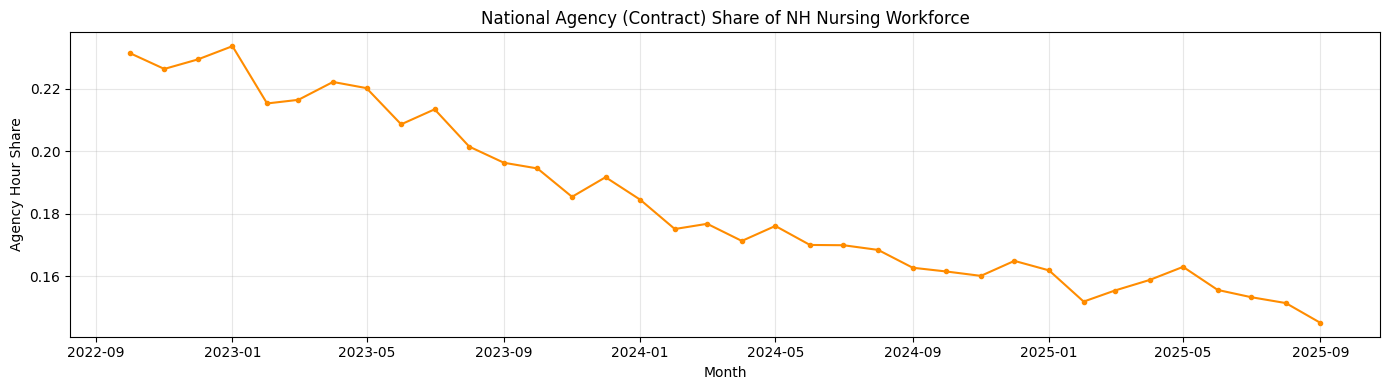

Agency share range: 0.145 to 0.234


In [11]:
# Compute agency share at state x role x month level
agg = clean.groupby(['state', 'role', 'month_end', 'worker_type']).agg(
    active=('active_count', 'sum')
).reset_index()

total = agg.groupby(['state', 'role', 'month_end'])['active'].sum().reset_index(name='total_active')
contract = agg[agg['worker_type'] == 'Contract'][['state', 'role', 'month_end', 'active']].rename(columns={'active': 'contract_active'})

agency_share = total.merge(contract, on=['state', 'role', 'month_end'], how='left')
agency_share['contract_active'] = agency_share['contract_active'].fillna(0)
agency_share['agency_share'] = agency_share['contract_active'] / agency_share['total_active']

# National trend
national_agency = agency_share.groupby('month_end').apply(
    lambda g: g['contract_active'].sum() / g['total_active'].sum(),
    include_groups=False
).reset_index(name='agency_share')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(national_agency['month_end'], national_agency['agency_share'], marker='o', markersize=3, color='darkorange')
ax.set_xlabel('Month')
ax.set_ylabel('Agency Hour Share')
ax.set_title('National Agency (Contract) Share of NH Nursing Workforce')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Agency share range: {national_agency['agency_share'].min():.3f} to {national_agency['agency_share'].max():.3f}")